#3. Baseline OCR Pipeline

In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/capstone'
print(f"Working from: {BASE}")

Mounted at /content/drive
Working from: /content/drive/MyDrive/capstone


In [2]:
import random
import numpy as np
import torch
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SUBSET_TRAIN = 4000
SUBSET_VAL   = 500
SUBSET_TEST  = 500
IMG_SIZE     = (224, 224)

print(f"Seed: {SEED} | Device: {DEVICE}")
print(f"Train: {SUBSET_TRAIN} | Val: {SUBSET_VAL} | Test: {SUBSET_TEST}")

Seed: 42 | Device: cpu
Train: 4000 | Val: 500 | Test: 500


In [3]:
!pip install datasets==2.14.6 --quiet
!pip install transformers==4.40.0 --quiet
!apt-get install -y tesseract-ocr tesseract-ocr-eng --quiet
!pip install pytesseract pillow opencv-python-headless --quiet
!pip install scikit-learn pandas matplotlib seaborn tqdm --quiet
print("All packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 493.7/493.7 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 8.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2023.10.0 which is incompatible.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json
import time
import pytesseract
from PIL import Image, ImageFilter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from tqdm import tqdm

print("All imports ok")

All imports ok


In [5]:
from datasets import load_dataset

print("Loading RVL-CDIP...")

train_ds = load_dataset("rvl_cdip", split="train", streaming=True)
val_ds   = load_dataset("rvl_cdip", split="validation", streaming=True)
test_ds  = load_dataset("rvl_cdip", split="test", streaming=True)

train_list = list(train_ds.take(SUBSET_TRAIN))
val_list   = list(val_ds.take(SUBSET_VAL))
test_list  = list(test_ds.take(SUBSET_TEST))

LABEL_NAMES = ['letter', 'form', 'email', 'handwritten', 'advertisement',
               'scientific report', 'scientific publication', 'specification',
               'file folder', 'news article', 'budget', 'invoice',
               'presentation', 'questionnaire', 'resume', 'memo']
NUM_CLASSES = len(LABEL_NAMES)

print(f"Train: {len(train_list)} | Val: {len(val_list)} | Test: {len(test_list)}")
print(f"Classes: {NUM_CLASSES}")

Loading RVL-CDIP...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Train: 4000 | Val: 500 | Test: 500
Classes: 16


In [6]:
def preprocess_for_ocr(pil_img):
    #keeping original size for better text extraction
    gray     = pil_img.convert('L')
    denoised = gray.filter(ImageFilter.MedianFilter(size=3))
    #Resinzing after OCR
    return denoised

def extract_text(pil_img):
    processed = preprocess_for_ocr(pil_img)
    text = pytesseract.image_to_string(processed, config='--psm 6')
    return text.strip()

In [7]:
def extract_text(pil_img):
    processed = preprocess_for_ocr(pil_img)
    text = pytesseract.image_to_string(processed, config='--psm 6')
    return text.strip()

#Testing on one sample first
print("Testing OCR on one sample...")
sample = train_list[0]
text   = extract_text(sample['image'])
label  = LABEL_NAMES[sample['label']]
print(f"Label : {label}")
print(f"Text  : {text[:300]}")

Testing OCR on one sample...
Label : invoice
Text  : es Oe
Joes
ative
i Creat! INVOICE NO. [ew
| Gomenurn Joa |
Communication, DATES
Inc. ACCOUNT NO. les |
1899 recep nererence| Bor eee |
P.O. how 1ee3e
St Lads, pe eas 1 x
INVOICE
WE. RA Veatch RELEASED
Bron 6 Mei Vitarwen Tbs Corp
1600 West Hil) Strece UND 1 ee
B. 0. mom 35690 JUN2 1 pa
Modsvilie, iy


In [8]:
#Checking if already extracted and saved
train_text_path = f"{BASE}/data/train_texts.json"

if os.path.exists(train_text_path):
    print("Loading saved train texts from Drive...")
    with open(train_text_path, "r") as f:
        train_texts = json.load(f)
    print(f"Loaded {len(train_texts)} texts.")
else:
    print(f"Extracting OCR text from {SUBSET_TRAIN} training images...")
    train_texts = []
    for item in tqdm(train_list):
        text = extract_text(item['image'])
        train_texts.append(text)

    with open(train_text_path, "w") as f:
        json.dump(train_texts, f)
    print(f"Saved {len(train_texts)} texts to Drive.")

train_labels = [item['label'] for item in train_list]
print(f"Train texts: {len(train_texts)} | Labels: {len(train_labels)}")

Loading saved train texts from Drive...
Loaded 4000 texts.
Train texts: 4000 | Labels: 4000


In [9]:
val_text_path = f"{BASE}/data/val_texts.json"

if os.path.exists(val_text_path):
    print("Loading saved val texts from Drive...")
    with open(val_text_path, "r") as f:
        val_texts = json.load(f)
    print(f"Loaded {len(val_texts)} texts.")
else:
    print(f"Extracting OCR text from {SUBSET_VAL} val images...")
    val_texts = []
    for item in tqdm(val_list):
        text = extract_text(item['image'])
        val_texts.append(text)

    with open(val_text_path, "w") as f:
        json.dump(val_texts, f)
    print(f"Saved {len(val_texts)} val texts to Drive.")

val_labels = [item['label'] for item in val_list]
print(f"Val texts: {len(val_texts)} | Labels: {len(val_labels)}")

Extracting OCR text from 500 val images...


100%|██████████| 500/500 [36:35<00:00,  4.39s/it]

Saved 500 val texts to Drive.
Val texts: 500 | Labels: 500


In [10]:
print("Fitting TF-IDF vectorizer...")

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(train_texts)
X_val   = vectorizer.transform(val_texts)

print(f"X_train shape : {X_train.shape}")
print(f"X_val shape   : {X_val.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

Fitting TF-IDF vectorizer...
X_train shape : (4000, 5000)
X_val shape   : (500, 5000)
Vocabulary size: 5000


In [11]:
print("Training LinearSVC...")

start = time.time()
svm_clf = LinearSVC(max_iter=2000, random_state=SEED)
svm_clf.fit(X_train, train_labels)
elapsed = time.time() - start

print(f"Training complete in {elapsed:.1f}s")

Training LinearSVC...
Training complete in 1.6s


In [12]:
print("Evaluating SVM on validation set...")

start     = time.time()
svm_preds = svm_clf.predict(X_val)
svm_time  = (time.time() - start) / len(val_texts)

svm_acc = accuracy_score(val_labels, svm_preds)
svm_f1  = f1_score(val_labels, svm_preds, average='macro', zero_division=0)

print(f"Accuracy      : {svm_acc:.4f}")
print(f"Macro F1      : {svm_f1:.4f}")
print(f"Inference time: {svm_time*1000:.2f} ms/image")
print()
print(classification_report(val_labels, svm_preds,
                             target_names=LABEL_NAMES, zero_division=0))

Evaluating SVM on validation set...
Accuracy      : 0.5660
Macro F1      : 0.5643
Inference time: 0.01 ms/image

                        precision    recall  f1-score   support

                letter       0.50      0.62      0.55        21
                  form       0.53      0.56      0.55        32
                 email       0.81      0.74      0.77        34
           handwritten       0.32      0.32      0.32        31
         advertisement       0.56      0.56      0.56        34
     scientific report       0.48      0.29      0.36        35
scientific publication       0.70      0.65      0.68        40
         specification       0.50      0.72      0.59        18
           file folder       0.43      0.62      0.51        32
          news article       0.44      0.55      0.49        31
                budget       0.52      0.48      0.50        33
               invoice       0.43      0.41      0.42        29
          presentation       0.61      0.46      0.52 

In [13]:
print("Training Logistic Regression...")

start  = time.time()
lr_clf = LogisticRegression(max_iter=1000, random_state=SEED,
                             solver='lbfgs', multi_class='multinomial')
lr_clf.fit(X_train, train_labels)
elapsed = time.time() - start

print(f"Training complete in {elapsed:.1f}s")

lr_preds = lr_clf.predict(X_val)
lr_acc   = accuracy_score(val_labels, lr_preds)
lr_f1    = f1_score(val_labels, lr_preds, average='macro', zero_division=0)

print(f"Accuracy : {lr_acc:.4f}")
print(f"Macro F1 : {lr_f1:.4f}")

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training complete in 8.2s
Accuracy : 0.5580
Macro F1 : 0.5685


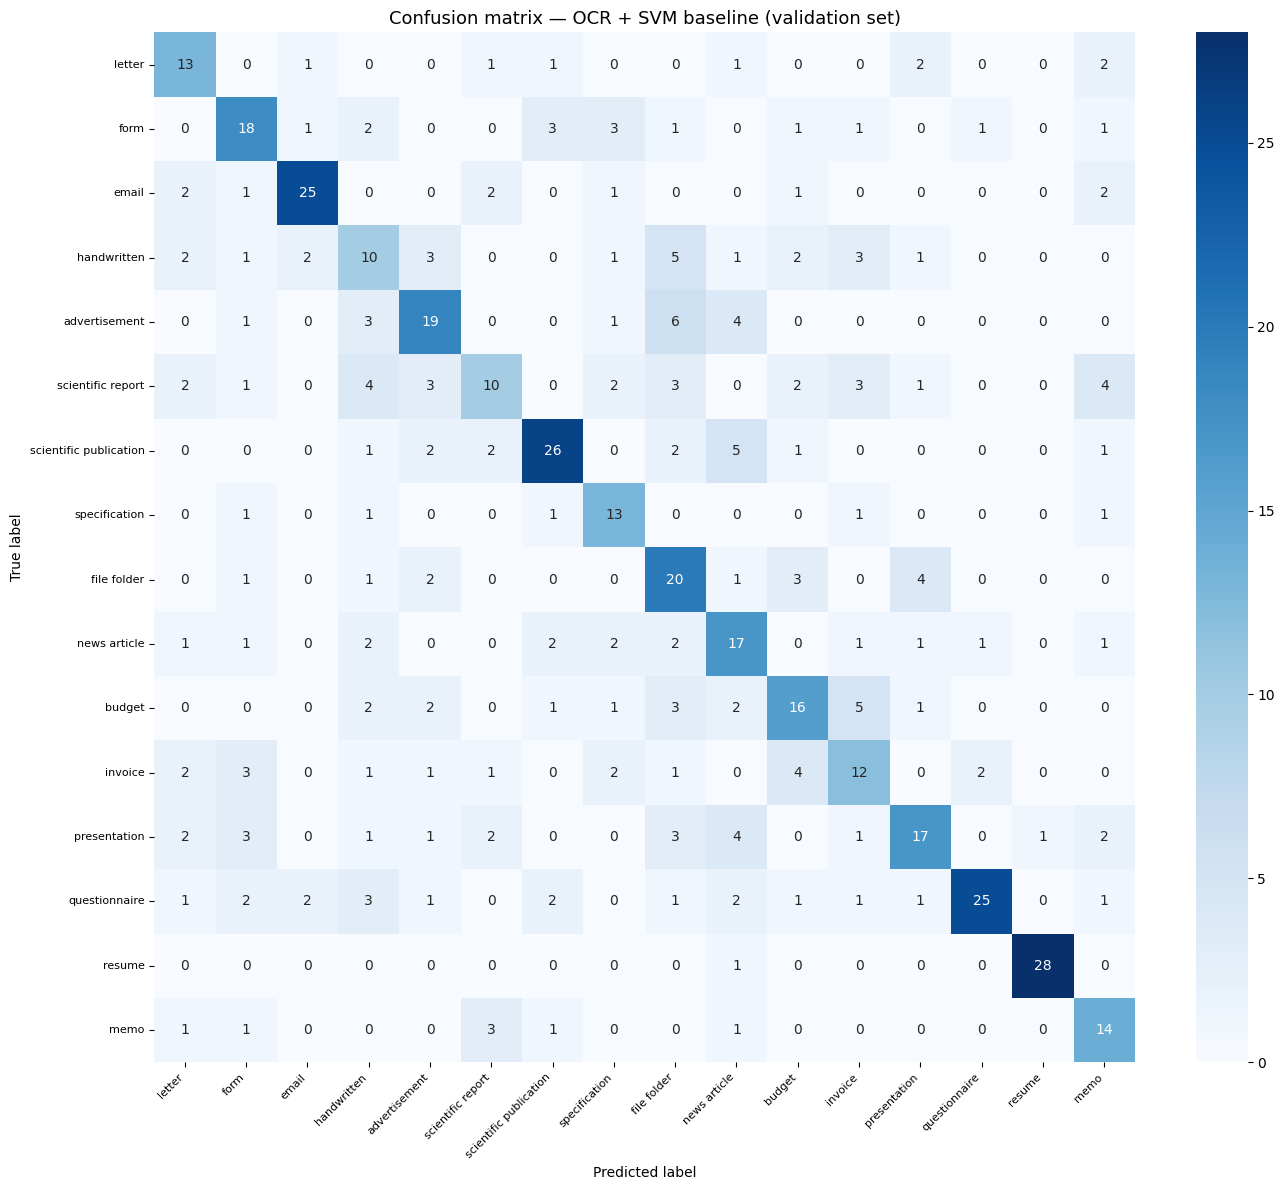

Confusion matrix saved.


In [14]:
cm = confusion_matrix(val_labels, svm_preds)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES,
            cmap='Blues', ax=ax)
ax.set_title("Confusion matrix — OCR + SVM baseline (validation set)",
             fontsize=13)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/baseline_confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved.")

/tmp/ipykernel_16156/2898274203.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(LABEL_NAMES, rotation=45, ha='right', fontsize=9)


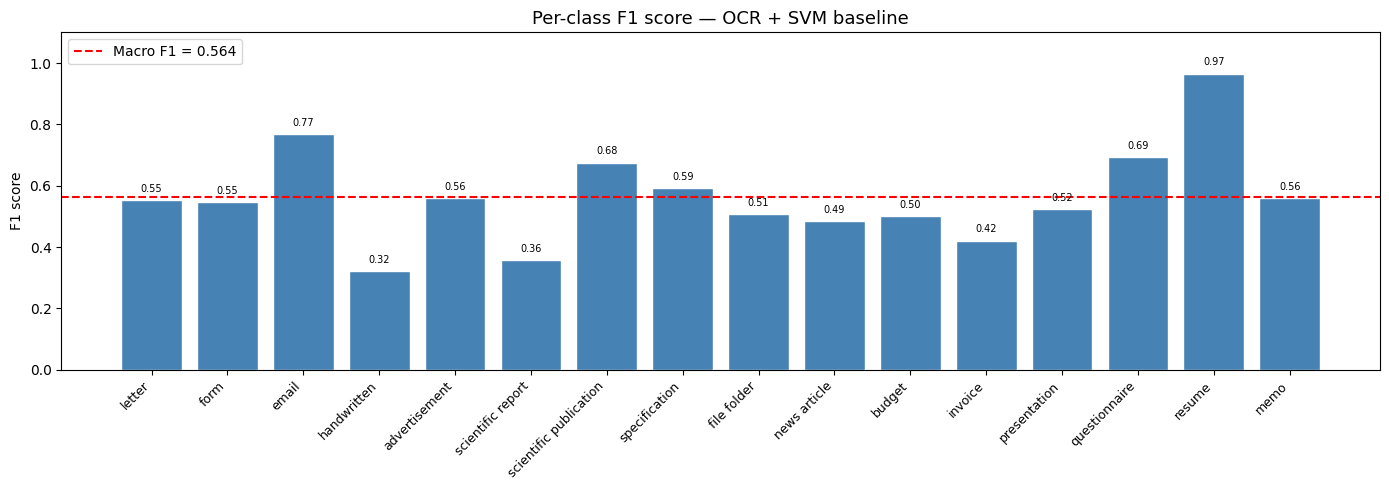

Per-class F1 chart saved.


In [15]:
report_dict = classification_report(val_labels, svm_preds,
                                     target_names=LABEL_NAMES,
                                     output_dict=True,
                                     zero_division=0)

per_class_f1 = [report_dict[cls]['f1-score'] for cls in LABEL_NAMES]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(LABEL_NAMES, per_class_f1, color='steelblue', edgecolor='white')
ax.set_title("Per-class F1 score — OCR + SVM baseline", fontsize=13)
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1.1)
ax.set_xticklabels(LABEL_NAMES, rotation=45, ha='right', fontsize=9)
ax.axhline(y=svm_f1, color='red', linestyle='--',
           label=f'Macro F1 = {svm_f1:.3f}')
ax.legend()

for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/baseline_per_class_f1.png", dpi=150)
plt.show()
print("Per-class F1 chart saved.")

In [19]:
results = {
    "model"         : "OCR + TF-IDF + LinearSVC",
    "dataset"       : "RVL-CDIP subset",
    "train_samples" : SUBSET_TRAIN,
    "val_samples"   : SUBSET_VAL,
    "accuracy"      : round(svm_acc, 4),
    "macro_f1"      : round(svm_f1, 4),
    "inference_ms"  : round(svm_time * 1000, 2),
    "tfidf_features": 5000,
    "ngram_range"   : "(1, 2)",
    "random_seed"   : SEED
}

results_path = f"{BASE}/outputs/results/baseline_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

#Saving classification report as text
report_text = classification_report(val_labels, svm_preds,
                                     target_names=LABEL_NAMES,
                                     zero_division=0)
with open(f"{BASE}/outputs/results/baseline_classification_report.txt", "w") as f:
    f.write(report_text)

print("Results saved:")
print(json.dumps(results, indent=2))

Results saved:
{
  "model": "OCR + TF-IDF + LinearSVC",
  "dataset": "RVL-CDIP subset",
  "train_samples": 4000,
  "val_samples": 500,
  "accuracy": 0.566,
  "macro_f1": 0.5643,
  "inference_ms": 0.01,
  "tfidf_features": 5000,
  "ngram_range": "(1, 2)",
  "random_seed": 42
}


In [20]:
#Finding misclassified samples
errors = [(i, val_labels[i], svm_preds[i])
          for i in range(len(val_labels))
          if val_labels[i] != svm_preds[i]]

print(f"Total misclassified : {len(errors)} / {len(val_labels)}")
print(f"Accuracy            : {1 - len(errors)/len(val_labels):.4f}")
print()

#Most common misclassification pairs
from collections import Counter
pairs = Counter([(LABEL_NAMES[t], LABEL_NAMES[p]) for _, t, p in errors])
print("Top 10 misclassification pairs (true → predicted):")
for (true, pred), count in pairs.most_common(10):
    print(f"  {true:30s} → {pred:30s} : {count}")

Total misclassified : 217 / 500
Accuracy            : 0.5660

Top 10 misclassification pairs (true → predicted):
  advertisement                  → file folder                    : 6
  budget                         → invoice                        : 5
  handwritten                    → file folder                    : 5
  scientific publication         → news article                   : 5
  scientific report              → memo                           : 4
  scientific report              → handwritten                    : 4
  file folder                    → presentation                   : 4
  presentation                   → news article                   : 4
  invoice                        → budget                         : 4
  advertisement                  → news article                   : 4
